# StaticSpinSucep: spin susceptibility from excitonic BSE

This notebook separates the spin-susceptibility problem from the excitonic Bethe-Salpeter notebook. The goal is to build, on a fixed magnetic background, the benchmark electronic bubble and the leading Gaussian excitonic corrections:

$$R^R = R^R_{\rm bare} + R^R_{1D} + R^R_{2D},$$

where $R_{\rm bare}$ is the electronic spin-spin bubble, $R_{1D}$ contains one excitonic propagator $D$ and one two-spin vertex $\partial_M\partial_M\Pi$, and $R_{2D}$ contains two excitonic propagators and two one-spin vertices $\partial_M\Pi$.



## Objects to compute

The retarded spin susceptibility is

$$R^{ab,R}_{ll'}(t)=-i\Theta(t)\langle [s_l^a(t),s_{l'}^b(0)]\rangle,$$

with layer indices $l,l'=1,2$ and spin indices $a,b=x,y,z$. We use

$$s_l^a=\frac{1}{2}c_l^\dagger\sigma^a c_l.$$

For a Hamiltonian without inter-layer tunneling, the electronic benchmark is layer diagonal:

$$R^{ab,R}_{ll',\mathrm{bare}}\propto\delta_{ll'}.$$

The excitonic part starts from the channel-space BSE propagator

$$D^{-1}_{M,\mu\nu}(z,z')=\frac{\delta_{\mu\nu}\delta_C(z,z')}{V}-\Pi_{\mu\nu}(z,z';M),$$

where $\mu,\nu=0,x,y,z$ are excitonic charge/spin-channel indices. The bubble is

$$\Pi_{\mu\nu}(z,z';M)= -\frac{i}{L}\sum_k\mathrm{Tr}_{\sigma}\left[\Gamma_\mu^\dagger G^1_M(k;z,z')\Gamma_\nu G^2_M(k;z',z)\right].$$

For a static magnetic background $M_0$, time-translation invariance lets us use the retarded frequency representation

$$\Pi_{\mu\nu}(z,z';M_0)\rightarrow \Pi^R_{\mu\nu}(\omega;M_0),\qquad D_{M,\mu\nu}(z,z')\rightarrow D^R_{\mu\nu}(\omega;M_0).$$

The single-$D$ excitonic correction contains the two-magnetization vertex

$$\Lambda^{ll',ab,R}_{\mu\nu}(\omega;M_0)\equiv\frac{\partial^2\Pi^R_{\mu\nu}(\omega;M_0)}{\partial M_l^a\partial M_{l'}^b},$$

and is evaluated as

$$R^{ab,R}_{1D,ll'}(\omega;M_0)=C_{1D}\sum_{\mu\nu}D^R_{\mu\nu}(\omega;M_0)\Lambda^{ll',ab,R}_{\nu\mu}(\omega;M_0).$$

The two-$D$ excitonic correction uses the one-magnetization vertex

$$\Lambda^{l,a,R}_{\mu\nu}(\omega;M_0)\equiv\frac{\partial\Pi^R_{\mu\nu}(\omega;M_0)}{\partial M_l^a},$$

and is evaluated in the same static-background approximation as

$$R^{ab,R}_{2D,ll'}(\omega;M_0)=C_{2D}\,\mathrm{Tr}_{\mu}\left[D^R(\omega)\Lambda^{l,a,R}(\omega)D^R(\omega)\Lambda^{l',b,R}(\omega)\right].$$



In [83]:
using LinearAlgebra
using Printf
using PyPlot

rc("font", family="serif")
rc("font", size=13)
rc("axes", labelsize=14, titlesize=14)
rc("legend", fontsize=10);


In [96]:
# -----------------------------
# Physical and numerical parameters
# -----------------------------
L = 100
γ = 1.0
Δ_layer = 8.0
Jsd = 0.35
Mmag = 1.0
θ = pi/4
V = -1.2
T = 0.08#0.2#0.08

# Chemical potentials diagonal in the Hamiltonian.
μchem = 0.0
μbias = 0.0
μ1 = μchem + μbias/2
μ2 = μchem - μbias/2

ηΩ = 0.25#32#16
Ωmin, Ωmax, NΩ = 0.0, 15.0, 401

ks = collect(range(-π, stop=π - 2π/L, length=L))
Ωs = collect(range(Ωmin, Ωmax, length=NΩ));


In [97]:
# Pauli matrices in physical spin space.
σ0 = ComplexF64[1 0; 0 1]
σx = ComplexF64[0 1; 1 0]
σy = ComplexF64[0 -1im; 1im 0]
σz = ComplexF64[1 0; 0 -1]

# Physical spin vertices s^a = sigma^a/2.
S_spin = [σx, σy, σz] ./ 2
spin_labels = ["x", "y", "z"]

# Excitonic vertices Gamma^mu = sigma^mu/sqrt(2), mu=0,x,y,z.
Γ_exciton = [σ0, σx, σy, σz] ./ sqrt(2)
channel_labels = ["0", "x", "y", "z"];


In [98]:
ϵk(k; γ=γ) = -2γ*cos(k)

function fermi(E; T=T, μ=0.0)
    x = (E - μ) / T
    x > 60 && return 0.0
    x < -60 && return 1.0
    return 1 / (exp(x) + 1)
end

layer_chemical_potential(layer::Int) = layer == 1 ? μ1 : μ2

function h_layer(k, M; layer::Int)
    offset = layer == 1 ? +Δ_layer/2 : Δ_layer/2
    energy = (ϵk(k) + offset) * σ0 - Jsd * (M[1]*σx + M[2]*σy + M[3]*σz)
    energy .*= (-1)^(layer+1)
    energy .-= layer_chemical_potential(layer) * σ0
    return energy
end

function magnetizations(θ)
    M1 = Mmag .* [0.0, 0.0, 1.0]
    M2 = Mmag .* [sin(θ), 0.0, cos(θ)]
    return M1, M2
end

function diagonalize_layers(ks, θ)
    M1, M2 = magnetizations(θ)
    E1 = zeros(Float64, 2, length(ks))
    E2 = zeros(Float64, 2, length(ks))
    U1 = Vector{Matrix{ComplexF64}}(undef, length(ks))
    U2 = Vector{Matrix{ComplexF64}}(undef, length(ks))

    for (ik, k) in enumerate(ks)
        F1 = eigen(Hermitian(h_layer(k, M1; layer=1)))
        F2 = eigen(Hermitian(h_layer(k, M2; layer=2)))
        E1[:, ik] .= F1.values
        E2[:, ik] .= F2.values
        U1[ik] = Matrix{ComplexF64}(F1.vectors)
        U2[ik] = Matrix{ComplexF64}(F2.vectors)
    end

    return (; M1, M2, E1, E2, U1, U2)
end;


## $R_{\rm bare}$: electronic spin-spin bubble

In equilibrium we use the retarded band expression

$$R^{ab,R}_{l,{\rm bare}}(\Omega)=\frac{1}{L}\sum_{k,n,m}\frac{f(E_{lnk})-f(E_{lmk})}{\Omega+i\eta-(E_{lmk}-E_{lnk})}\,S^a_{nm}(k)S^b_{mn}(k).$$

Because there is no inter-layer tunneling, this contribution is diagonal in layer: $R_{12,{\rm bare}}=R_{21,{\rm bare}}=0$.


In [99]:
function spin_susceptibility_bare_band(Ωs, ks, θ; η=ηΩ)
    data = diagonalize_layers(ks, θ)
    R = zeros(ComplexF64, 2, 2, 3, 3, length(Ωs))

    for layer in 1:2
        E = layer == 1 ? data.E1 : data.E2
        U = layer == 1 ? data.U1 : data.U2

        for (ik, _) in enumerate(ks)
            Uk = U[ik]
            Sa = [Uk' * S_spin[a] * Uk for a in 1:3]

            for n in 1:2, m in 1:2
                ΔE = E[m, ik] - E[n, ik]
                occ = fermi(E[n, ik]) - fermi(E[m, ik])

                for (iΩ, Ω) in enumerate(Ωs)
                    pref = occ / (Ω + 1im*η - ΔE) / length(ks)
                    for a in 1:3, b in 1:3
                        R[layer, layer, a, b, iΩ] += pref * Sa[a][n, m] * Sa[b][m, n]
                    end
                end
            end
        end
    end

    return R, data
end;


## $R_{1D}$: excitonic term with a single $D$

The next contribution comes from

$$i\mathrm{Tr}\ln D_M^{-1},\qquad D_M^{-1}=V^{-1}-\Pi[M].$$

Taking two derivatives with respect to the classical moments gives a term with one excitonic propagator and one two-magnetization vertex:

$$R^{ab,R}_{1D,ll'}(\omega;M_0)=C_{1D}\sum_{\mu\nu}D^R_{\mu\nu}(\omega;M_0)\Lambda^{ll',ab,R}_{\nu\mu}(\omega;M_0),$$

with

$$\Lambda^{ll',ab,R}_{\mu\nu}(\omega;M_0)=\partial_{M_l^a}\partial_{M_{l'}^b}\Pi^R_{\mu\nu}(\omega;M_0).$$

This is the static-background version of the two-vertex object in the document. The word "two-vertex" here refers to the two spin/magnetization insertions inside $\Lambda_{ab}$, not to the later term with two separate excitonic propagators.

For example, the contour object corresponding to one cross-layer component has the indexed structure

$$\Lambda^{21}_{ab,\mu\nu}(z,z';\bar z,\bar z')\propto -\frac{iJ_{sd}^2}{L}\sum_k\mathrm{Tr}_{\sigma}\left[\Gamma_\mu G^2_M(z,\bar z)\sigma_aG^2_M(\bar z,z')\Gamma_\nu G^1_M(z',\bar z')\sigma_bG^1_M(\bar z',z)\right],$$

up to the precise contour ordering and sign convention. The important point for the notebook is that $\Lambda^{ll',ab}_{\mu\nu}$ remains a $4\times4$ matrix in excitonic channel space before being contracted with $D_{\mu\nu}$.


In [100]:
function diagonalize_layers_from_M(ks, M1, M2)
    E1 = zeros(Float64, 2, length(ks))
    E2 = zeros(Float64, 2, length(ks))
    U1 = Vector{Matrix{ComplexF64}}(undef, length(ks))
    U2 = Vector{Matrix{ComplexF64}}(undef, length(ks))

    for (ik, k) in enumerate(ks)
        F1 = eigen(Hermitian(h_layer(k, M1; layer=1)))
        F2 = eigen(Hermitian(h_layer(k, M2; layer=2)))
        E1[:, ik] .= F1.values
        E2[:, ik] .= F2.values
        U1[ik] = Matrix{ComplexF64}(F1.vectors)
        U2[ik] = Matrix{ComplexF64}(F2.vectors)
    end

    return (; M1, M2, E1, E2, U1, U2)
end

function polarization_R_band_from_M(Ωs, ks, M1, M2; η=ηΩ)
    data = diagonalize_layers_from_M(ks, M1, M2)
    Π = zeros(ComplexF64, 4, 4, length(Ωs))

    for (ik, _) in enumerate(ks)
        U1k = data.U1[ik]
        U2k = data.U2[ik]
        Mμ = [U1k' * Γ_exciton[μ] * U2k for μ in 1:4]

        for a in 1:2, b in 1:2
            ΔE = data.E1[a, ik] - data.E2[b, ik]
            occ = fermi(data.E2[b, ik]) - fermi(data.E1[a, ik])

            for (iΩ, Ω) in enumerate(Ωs)
                pref = occ / (Ω + 1im*η - ΔE) / length(ks)
                for μ in 1:4, ν in 1:4
                    Π[μ, ν, iΩ] += pref * Mμ[μ][a, b] * conj(Mμ[ν][a, b])
                end
            end
        end
    end

    return Π, data
end

function exciton_propagator(Π; V=V)
    D = similar(Π)
    VinvI = (1/V) * Matrix{ComplexF64}(I, 4, 4)
    for iΩ in axes(Π, 3)
        D[:, :, iΩ] .= inv(VinvI - Π[:, :, iΩ])
    end
    return D
end;


## Explicit retarded two-magnetization vertex

The object needed for the single-$D$ correction is the analytic two-spin vertex

$$\Lambda^{ll',ab,R}_{\mu\nu}(\Omega;M_0)=\partial_{M_l^a}\partial_{M_{l'}^b}\Pi^R_{\mu\nu}(\Omega;M_0).$$

In practice we do not evaluate this by finite differences. The derivatives generate explicit spin insertions on the electronic Green functions. For the static background, the retarded bubble is obtained from the contour bubble by the Langreth rule

$$\Pi^R_{\mu\nu}(\Omega)=-\frac{i}{L}\sum_k\int\frac{d\omega}{2\pi}\mathrm{Tr}_\sigma\left[\Gamma_\mu^\dagger G^{1,R}(\omega+\Omega)\Gamma_\nu G^{2,<}(\omega)+\Gamma_\mu^\dagger G^{1,<}(\omega+\Omega)\Gamma_\nu G^{2,A}(\omega)\right].$$

The same Langreth structure applies after the spin insertions are included. For example, a first insertion on layer $l$ is

$$\partial_{M_l^a}G_l^R=G_l^R h_l^a G_l^R,\qquad h_l^a\equiv\partial_{M_l^a}H_l=(-1)^{l+1}(-J_{sd})\sigma^a,$$

and in equilibrium

$$\partial_{M_l^a}G_l^< = f(\omega)\left(\partial_{M_l^a}G_l^A-\partial_{M_l^a}G_l^R\right),$$

which is equivalent to applying the full Langreth rule to $G h_l^a G$. For two insertions on the same layer, because $H_l$ is linear in $M_l$,

$$\partial_{M_l^a}\partial_{M_l^b}G_l^X = G_l^X h_l^bG_l^X h_l^aG_l^X+G_l^X h_l^aG_l^X h_l^bG_l^X,$$

with $X=R,A,<$. Thus `:langreth` evaluates the analytic vertex with the explicit internal-frequency integral.


In [101]:
# Independent internal-frequency grid for the explicit Langreth vertex.
ωv_min, ωv_max, Nωv = -15.0, 15.0, 401
ωs_vertex = collect(range(ωv_min, ωv_max, length=Nωv))
dω_vertex = ωs_vertex[2] - ωs_vertex[1]

# Electronic broadening used inside the explicit Green functions.
ηe = ηΩ / 2;


In [102]:
function green_R(h, ω; η=ηe)
    return inv((ω + 1im*η) * σ0 - h)
end

green_A(h, ω; η=ηe) = green_R(h, ω; η=η)'

green_less(h, ω; η=ηe) = fermi(ω) * (green_A(h, ω; η=η) - green_R(h, ω; η=η))

function dh_dM(layer::Int, comp::Int)
    # This derivative follows the current h_layer convention, including the layer-dependent sign.
    layer_sign = (-1)^(layer + 1)
    return layer_sign * (-Jsd) * (2 * S_spin[comp])
end

function green_derivative(h, ω, dh; η=ηe)
    GR = green_R(h, ω; η=η)
    GA = GR'
    dGR = GR * dh * GR
    dGA = dGR'
    dGL = fermi(ω) * (dGA - dGR)
    return (; R=dGR, A=dGA, L=dGL)
end

function green_second_derivative(h, ω, dha, dhb; η=ηe)
    GR = green_R(h, ω; η=η)
    GA = GR'
    d2GR = GR * dhb * GR * dha * GR + GR * dha * GR * dhb * GR
    d2GA = d2GR'
    d2GL = fermi(ω) * (d2GA - d2GR)
    return (; R=d2GR, A=d2GA, L=d2GL)
end;


## Langreth evaluation of $\Lambda^{ll',ab,R}_{\mu\nu}$

The code below evaluates the analytic vertex using the retarded Langreth expression. This means that the internal frequency $\omega$ is kept explicitly and integrated numerically.

For $l=l'=1$, both spin insertions sit on the layer-1 line:

$$\Gamma_\mu^\dagger (\partial_a\partial_b G^{1,R})\Gamma_\nu G^{2,<}+\Gamma_\mu^\dagger (\partial_a\partial_b G^{1,<})\Gamma_\nu G^{2,A}.$$

For a cross-layer component, e.g. $l=2,l'=1$, one first derivative sits on each line:

$$\Gamma_\mu^\dagger (\partial_b G^{1,R})\Gamma_\nu(\partial_a G^{2,<})+\Gamma_\mu^\dagger (\partial_b G^{1,<})\Gamma_\nu(\partial_a G^{2,A}).$$

The full routine keeps all indices,

$$\Lambda[l,l',a,b,\mu,\nu,i\Omega],$$

while the faster reduced routine keeps only diagonal spin components $a=b$ for one selected layer pair.


In [103]:
function lambda_two_vertex_explicit_langreth(Ωs, ωs, ks, θ; η=ηe)
    M1, M2 = magnetizations(θ)
    Λ = zeros(ComplexF64, 2, 2, 3, 3, 4, 4, length(Ωs))
    dω_local = length(ωs) > 1 ? ωs[2] - ωs[1] : 1.0

    for k in ks
        h1 = h_layer(k, M1; layer=1)
        h2 = h_layer(k, M2; layer=2)
        dh = [[dh_dM(layer, comp) for comp in 1:3] for layer in 1:2]

        for (iΩ, Ω) in enumerate(Ωs)
            acc = zeros(ComplexF64, 2, 2, 3, 3, 4, 4)

            for ω in ωs
                G1R = green_R(h1, ω + Ω; η=η)
                G1A = G1R'
                G1L = fermi(ω + Ω) * (G1A - G1R)
                G2R = green_R(h2, ω; η=η)
                G2A = G2R'
                G2L = fermi(ω) * (G2A - G2R)

                dG1 = [green_derivative(h1, ω + Ω, dh[1][a]; η=η) for a in 1:3]
                dG2 = [green_derivative(h2, ω, dh[2][a]; η=η) for a in 1:3]
                d2G1 = [[green_second_derivative(h1, ω + Ω, dh[1][a], dh[1][b]; η=η) for b in 1:3] for a in 1:3]
                d2G2 = [[green_second_derivative(h2, ω, dh[2][a], dh[2][b]; η=η) for b in 1:3] for a in 1:3]

                for μ in 1:4, ν in 1:4
                    Γμ = Γ_exciton[μ]
                    Γν = Γ_exciton[ν]
                    Γμd = Γμ'

                    for a in 1:3, b in 1:3
                        # l=1, l'=1: both insertions on the layer-1 line.
                        acc[1, 1, a, b, μ, ν] += tr(Γμd * d2G1[a][b].R * Γν * G2L +
                                                     Γμd * d2G1[a][b].L * Γν * G2A)

                        # l=2, l'=2: both insertions on the layer-2 line.
                        acc[2, 2, a, b, μ, ν] += tr(Γμd * G1R * Γν * d2G2[a][b].L +
                                                     Γμd * G1L * Γν * d2G2[a][b].A)

                        # l=1, l'=2: first insertion on layer 1, second on layer 2.
                        acc[1, 2, a, b, μ, ν] += tr(Γμd * dG1[a].R * Γν * dG2[b].L +
                                                     Γμd * dG1[a].L * Γν * dG2[b].A)

                        # l=2, l'=1: first insertion on layer 2, second on layer 1.
                        acc[2, 1, a, b, μ, ν] += tr(Γμd * dG1[b].R * Γν * dG2[a].L +
                                                     Γμd * dG1[b].L * Γν * dG2[a].A)
                    end
                end
            end

            Λ[:, :, :, :, :, :, iΩ] .+= (-1im) .* acc .* dω_local ./ (2π * length(ks))
        end
    end

    return Λ
end

function spin_susceptibility_oneD_explicit_langreth(Ωs, ωs, ks, θ; η=ηe, prefactor=-1im)
    M1, M2 = magnetizations(θ)
    Π0, data0 = polarization_R_band_from_M(Ωs, ks, M1, M2; η=ηΩ)
    D = exciton_propagator(Π0; V=V)
    Λ = lambda_two_vertex_explicit_langreth(Ωs, ωs, ks, θ; η=η)
    R1D = zeros(ComplexF64, 2, 2, 3, 3, length(Ωs))

    for l in 1:2, lp in 1:2, a in 1:3, b in 1:3, iΩ in axes(Ωs, 1)
        acc = zero(ComplexF64)
        for μ in 1:4, ν in 1:4
            acc += D[μ, ν, iΩ] * Λ[l, lp, a, b, ν, μ, iΩ]
        end
        R1D[l, lp, a, b, iΩ] = prefactor * acc
    end

    return R1D, Λ, D, Π0, data0
end
function precompute_exciton_D(Ωs, ks, θ; V=V, η=ηΩ)
    M1, M2 = magnetizations(θ)
    Π, data = polarization_R_band_from_M(Ωs, ks, M1, M2; η=η)
    D = exciton_propagator(Π; V=V)
    return D, Π, data
end

function lambda_layerpair_diag_explicit_langreth(Ωs, ωs, ks, θ; layer_pair=(1, 1), η=ηe)
    l, lp = layer_pair
    @assert l in (1, 2) "l must be 1 or 2"
    @assert lp in (1, 2) "lp must be 1 or 2"

    M1, M2 = magnetizations(θ)
    Λdiag = zeros(ComplexF64, 3, 4, 4, length(Ωs))
    dω_local = length(ωs) > 1 ? ωs[2] - ωs[1] : 1.0
    dh1 = [dh_dM(1, a) for a in 1:3]
    dh2 = [dh_dM(2, a) for a in 1:3]

    for k in ks
        h1 = h_layer(k, M1; layer=1)
        h2 = h_layer(k, M2; layer=2)

        for (iΩ, Ω) in enumerate(Ωs)
            acc = zeros(ComplexF64, 3, 4, 4)

            for ω in ωs
                G1R = green_R(h1, ω + Ω; η=η)
                G1A = G1R'
                G1L = fermi(ω + Ω) * (G1A - G1R)

                G2R = green_R(h2, ω; η=η)
                G2A = G2R'
                G2L = fermi(ω) * (G2A - G2R)

                for a in 1:3
                    if l == 1 && lp == 1
                        d2G1R = 2 * G1R * dh1[a] * G1R * dh1[a] * G1R
                        d2G1A = d2G1R'
                        d2G1L = fermi(ω + Ω) * (d2G1A - d2G1R)

                        for μ in 1:4, ν in 1:4
                            Γμd = Γ_exciton[μ]'
                            Γν = Γ_exciton[ν]
                            acc[a, μ, ν] += tr(Γμd * d2G1R * Γν * G2L +
                                                Γμd * d2G1L * Γν * G2A)
                        end
                    elseif l == 2 && lp == 2
                        d2G2R = 2 * G2R * dh2[a] * G2R * dh2[a] * G2R
                        d2G2A = d2G2R'
                        d2G2L = fermi(ω) * (d2G2A - d2G2R)

                        for μ in 1:4, ν in 1:4
                            Γμd = Γ_exciton[μ]'
                            Γν = Γ_exciton[ν]
                            acc[a, μ, ν] += tr(Γμd * G1R * Γν * d2G2L +
                                                Γμd * G1L * Γν * d2G2A)
                        end
                    else
                        dG1R = G1R * dh1[a] * G1R
                        dG1A = dG1R'
                        dG1L = fermi(ω + Ω) * (dG1A - dG1R)

                        dG2R = G2R * dh2[a] * G2R
                        dG2A = dG2R'
                        dG2L = fermi(ω) * (dG2A - dG2R)

                        for μ in 1:4, ν in 1:4
                            Γμd = Γ_exciton[μ]'
                            Γν = Γ_exciton[ν]
                            acc[a, μ, ν] += tr(Γμd * dG1R * Γν * dG2L +
                                                Γμd * dG1L * Γν * dG2A)
                        end
                    end
                end
            end

            Λdiag[:, :, :, iΩ] .+= (-1im) .* acc .* dω_local ./ (2π * length(ks))
        end
    end

    return Λdiag
end

function contract_singleD_diag(D, Λdiag; prefactor=-1im)
    Rdiag = zeros(ComplexF64, 3, size(D, 3))

    for a in 1:3, iΩ in axes(D, 3)
        acc = zero(ComplexF64)
        for μ in 1:4, ν in 1:4
            acc += D[μ, ν, iΩ] * Λdiag[a, ν, μ, iΩ]
        end
        Rdiag[a, iΩ] = prefactor * acc
    end

    return Rdiag
end

function spin_susceptibility_oneD_diag_explicit_langreth(D, Ωs, ωs, ks, θ; layer_pair=(1, 1), η=ηe, prefactor=-1im)
    Λdiag = lambda_layerpair_diag_explicit_langreth(Ωs, ωs, ks, θ; layer_pair=layer_pair, η=η)
    Rdiag = contract_singleD_diag(D, Λdiag; prefactor=prefactor)
    return Rdiag, Λdiag
end

function spin_susceptibility_oneD_diag_explicit_langreth(Ωs, ωs, ks, θ; layer_pair=(1, 1), η=ηe, prefactor=-1im, V=V)
    D, Π, data = precompute_exciton_D(Ωs, ks, θ; V=V, η=ηΩ)
    Rdiag, Λdiag = spin_susceptibility_oneD_diag_explicit_langreth(D, Ωs, ωs, ks, θ; layer_pair=layer_pair, η=η, prefactor=prefactor)
    return Rdiag, Λdiag, D, Π, data
end;


## Fast Lehmann evaluation of the analytic vertex

The `:band` method evaluates the same analytic vertex in the eigenstate basis of $H_1(k)$ and $H_2(k)$. It is not a finite-difference derivative and it does not introduce a new approximation beyond the same equilibrium, static-background assumptions.

Starting from the vertex with explicit spin insertions, we insert resolutions of identity in each layer,

$$1_l=\sum_n |l,n,k\rangle\langle l,n,k|,$$

and transform the already-derived spin-insertion matrices and exciton vertices to the band basis. In the present Hamiltonian the derivative has already been taken, so

$$h_l^a\equiv\partial_{M_l^a}H_l=(-1)^{l+1}(-J_{sd})\sigma^a,$$

using the same layer-sign convention as `h_layer`. Thus

$$h^a_{1,pr}=\langle 1,p|h_1^a|1,r\rangle,\qquad h^a_{2,qs}=\langle 2,q|h_2^a|2,s\rangle,$$

$$\Gamma^\mu_{rq}=\langle 1,r|\Gamma_\mu|2,q\rangle.$$

The frequency integral over products of Green functions is then analytic. The result can be written compactly with divided differences of

$$K_\Omega(x,y)=\frac{f(y)-f(x)}{\Omega+i\eta-(x-y)},$$

where $x$ is a layer-1 eigenvalue and $y$ is a layer-2 eigenvalue. Two insertions on layer 1 use $K_\Omega^{[2,0]}$, two insertions on layer 2 use $K_\Omega^{[0,2]}$, and cross-layer insertions use $K_\Omega^{[1,1]}$. For example,

$$\Lambda^{12,aa,R}_{\mu\nu}=\frac{1}{L}\sum_{k,p,r,q,s}K_\Omega^{[1,1]}(E_{1p},E_{1r};E_{2q},E_{2s})h^a_{1,pr}\Gamma^\mu_{rq}h^a_{2,qs}(\Gamma^\nu_{ps})^*.$$

This is why `:band` no longer uses the auxiliary grid `ωsχ`; it is the eigenstate-basis evaluation of the same Langreth vertex after the equilibrium frequency integral has been done analytically.


In [104]:
function fermi_prime(E; T=T, μ=0.0)
    f = fermi(E; T=T, μ=μ)
    return -(f * (1 - f)) / T
end

function fermi_second(E; T=T, μ=0.0)
    f = fermi(E; T=T, μ=μ)
    return f * (1 - f) * (1 - 2f) / T^2
end

function kernel_K(Ω, x, y, η=ηΩ)
    q = Ω + 1im*η - x + y
    return (fermi(y) - fermi(x)) / q
end

function kernel_Kx(Ω, x, y, η=ηΩ)
    q = Ω + 1im*η - x + y
    n = fermi(y) - fermi(x)
    return -fermi_prime(x) / q + n / q^2
end

function kernel_Ky(Ω, x, y, η=ηΩ)
    q = Ω + 1im*η - x + y
    n = fermi(y) - fermi(x)
    return fermi_prime(y) / q - n / q^2
end

function kernel_Kxx(Ω, x, y, η=ηΩ)
    q = Ω + 1im*η - x + y
    n = fermi(y) - fermi(x)
    return -fermi_second(x) / q - 2 * fermi_prime(x) / q^2 + 2 * n / q^3
end

function kernel_Kyy(Ω, x, y, η=ηΩ)
    q = Ω + 1im*η - x + y
    n = fermi(y) - fermi(x)
    return fermi_second(y) / q - 2 * fermi_prime(y) / q^2 + 2 * n / q^3
end

function kernel_Kxy(Ω, x, y, η=ηΩ)
    q = Ω + 1im*η - x + y
    n = fermi(y) - fermi(x)
    return (fermi_prime(x) + fermi_prime(y)) / q^2 - 2 * n / q^3
end

same_node(a, b) = abs(a - b) < 1e-10

function dd1_x(Ω, x1, x2, y, η=ηΩ)
    same_node(x1, x2) && return kernel_Kx(Ω, x1, y, η)
    return (kernel_K(Ω, x1, y, η) - kernel_K(Ω, x2, y, η)) / (x1 - x2)
end

function dd1_y(Ω, x, y1, y2, η=ηΩ)
    same_node(y1, y2) && return kernel_Ky(Ω, x, y1, η)
    return (kernel_K(Ω, x, y1, η) - kernel_K(Ω, x, y2, η)) / (y1 - y2)
end

function dd2_x(Ω, x1, x2, x3, y, η=ηΩ)
    if same_node(x1, x2) && same_node(x2, x3)
        return kernel_Kxx(Ω, x1, y, η) / 2
    elseif same_node(x1, x2)
        return (kernel_Kx(Ω, x1, y, η) - dd1_x(Ω, x1, x3, y, η)) / (x1 - x3)
    elseif same_node(x2, x3)
        return (dd1_x(Ω, x1, x2, y, η) - kernel_Kx(Ω, x2, y, η)) / (x1 - x2)
    elseif same_node(x1, x3)
        return (kernel_Kx(Ω, x1, y, η) - dd1_x(Ω, x1, x2, y, η)) / (x1 - x2)
    else
        return (dd1_x(Ω, x1, x2, y, η) - dd1_x(Ω, x2, x3, y, η)) / (x1 - x3)
    end
end

function dd2_y(Ω, x, y1, y2, y3, η=ηΩ)
    if same_node(y1, y2) && same_node(y2, y3)
        return kernel_Kyy(Ω, x, y1, η) / 2
    elseif same_node(y1, y2)
        return (kernel_Ky(Ω, x, y1, η) - dd1_y(Ω, x, y1, y3, η)) / (y1 - y3)
    elseif same_node(y2, y3)
        return (dd1_y(Ω, x, y1, y2, η) - kernel_Ky(Ω, x, y2, η)) / (y1 - y2)
    elseif same_node(y1, y3)
        return (kernel_Ky(Ω, x, y1, η) - dd1_y(Ω, x, y1, y2, η)) / (y1 - y2)
    else
        return (dd1_y(Ω, x, y1, y2, η) - dd1_y(Ω, x, y2, y3, η)) / (y1 - y3)
    end
end

function dd_xy(Ω, x1, x2, y1, y2, η=ηΩ)
    if same_node(x1, x2) && same_node(y1, y2)
        return kernel_Kxy(Ω, x1, y1, η)
    elseif same_node(x1, x2)
        return (kernel_Kx(Ω, x1, y1, η) - kernel_Kx(Ω, x1, y2, η)) / (y1 - y2)
    elseif same_node(y1, y2)
        return (kernel_Ky(Ω, x1, y1, η) - kernel_Ky(Ω, x2, y1, η)) / (x1 - x2)
    else
        return (kernel_K(Ω, x1, y1, η) - kernel_K(Ω, x2, y1, η) -
                kernel_K(Ω, x1, y2, η) + kernel_K(Ω, x2, y2, η)) / ((x1 - x2) * (y1 - y2))
    end
end

function projectors_from_eigenvectors(U)
    return [U[:, n] * U[:, n]' for n in 1:2]
end

function lambda_layerpair_diag_band(Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ)
    l, lp = layer_pair
    @assert l in (1, 2) "l must be 1 or 2"
    @assert lp in (1, 2) "lp must be 1 or 2"

    data = diagonalize_layers(ks, θ)
    Λdiag = zeros(ComplexF64, 3, 4, 4, length(Ωs))
    dh1 = [dh_dM(1, a) for a in 1:3]
    dh2 = [dh_dM(2, a) for a in 1:3]

    for (ik, _) in enumerate(ks)
        E1 = data.E1[:, ik]
        E2 = data.E2[:, ik]
        U1 = data.U1[ik]
        U2 = data.U2[ik]
        dh1e = [U1' * dh1[a] * U1 for a in 1:3]
        dh2e = [U2' * dh2[a] * U2 for a in 1:3]
        Γe = [U1' * Γ_exciton[μ] * U2 for μ in 1:4]

        for (iΩ, Ω) in enumerate(Ωs)
            for a in 1:3, μ in 1:4, ν in 1:4
                acc = zero(ComplexF64)
                Γμ = Γe[μ]
                Γν = Γe[ν]
                h1a = dh1e[a]
                h2a = dh2e[a]

                if l == 1 && lp == 1
                    for p in 1:2, r in 1:2, s in 1:2, q in 1:2
                        coeff = 2 * dd2_x(Ω, E1[p], E1[r], E1[s], E2[q], η)
                        acc += coeff * h1a[p, r] * h1a[r, s] * Γμ[s, q] * conj(Γν[p, q])
                    end
                elseif l == 2 && lp == 2
                    for p in 1:2, q in 1:2, r in 1:2, s in 1:2
                        coeff = 2 * dd2_y(Ω, E1[p], E2[q], E2[r], E2[s], η)
                        acc += coeff * Γμ[p, q] * h2a[q, r] * h2a[r, s] * conj(Γν[p, s])
                    end
                else
                    for p in 1:2, r in 1:2, q in 1:2, s in 1:2
                        coeff = dd_xy(Ω, E1[p], E1[r], E2[q], E2[s], η)
                        acc += coeff * h1a[p, r] * Γμ[r, q] * h2a[q, s] * conj(Γν[p, s])
                    end
                end

                Λdiag[a, μ, ν, iΩ] += acc / length(ks)
            end
        end
    end

    return Λdiag, data
end

function spin_susceptibility_oneD_diag_band(D, Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ, prefactor=-1im)
    Λdiag, data = lambda_layerpair_diag_band(Ωs, ks, θ; layer_pair=layer_pair, η=η)
    Rdiag = contract_singleD_diag(D, Λdiag; prefactor=prefactor)
    return Rdiag, Λdiag, data
end

function spin_susceptibility_oneD_diag_band(Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ, prefactor=-1im, V=V)
    D, Π, dataD = precompute_exciton_D(Ωs, ks, θ; V=V, η=η)
    Rdiag, Λdiag, dataΛ = spin_susceptibility_oneD_diag_band(D, Ωs, ks, θ; layer_pair=layer_pair, η=η, prefactor=prefactor)
    return Rdiag, Λdiag, D, Π, dataD, dataΛ
end;

function lambda_layerpair_full_band(Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ)
    l, lp = layer_pair
    @assert l in (1, 2) "l must be 1 or 2"
    @assert lp in (1, 2) "lp must be 1 or 2"

    data = diagonalize_layers(ks, θ)
    Λ = zeros(ComplexF64, 3, 3, 4, 4, length(Ωs))
    dh1 = [dh_dM(1, a) for a in 1:3]
    dh2 = [dh_dM(2, a) for a in 1:3]

    for (ik, _) in enumerate(ks)
        E1 = data.E1[:, ik]
        E2 = data.E2[:, ik]
        U1 = data.U1[ik]
        U2 = data.U2[ik]
        dh1e = [U1' * dh1[a] * U1 for a in 1:3]
        dh2e = [U2' * dh2[a] * U2 for a in 1:3]
        Γe = [U1' * Γ_exciton[μ] * U2 for μ in 1:4]

        for (iΩ, Ω) in enumerate(Ωs)
            for a in 1:3, b in 1:3, μ in 1:4, ν in 1:4
                acc = zero(ComplexF64)
                Γμ = Γe[μ]
                Γν = Γe[ν]
                h1a = dh1e[a]
                h1b = dh1e[b]
                h2a = dh2e[a]
                h2b = dh2e[b]

                if l == 1 && lp == 1
                    for p in 1:2, r in 1:2, s in 1:2, q in 1:2
                        coeff = dd2_x(Ω, E1[p], E1[r], E1[s], E2[q], η)
                        acc += coeff * (h1b[p, r] * h1a[r, s] + h1a[p, r] * h1b[r, s]) * Γμ[s, q] * conj(Γν[p, q])
                    end
                elseif l == 2 && lp == 2
                    for p in 1:2, q in 1:2, r in 1:2, s in 1:2
                        coeff = dd2_y(Ω, E1[p], E2[q], E2[r], E2[s], η)
                        acc += coeff * Γμ[p, q] * (h2a[q, r] * h2b[r, s] + h2b[q, r] * h2a[r, s]) * conj(Γν[p, s])
                    end
                elseif l == 1 && lp == 2
                    for p in 1:2, r in 1:2, q in 1:2, s in 1:2
                        coeff = dd_xy(Ω, E1[p], E1[r], E2[q], E2[s], η)
                        acc += coeff * h1a[p, r] * Γμ[r, q] * h2b[q, s] * conj(Γν[p, s])
                    end
                else
                    for p in 1:2, r in 1:2, q in 1:2, s in 1:2
                        coeff = dd_xy(Ω, E1[p], E1[r], E2[q], E2[s], η)
                        acc += coeff * h1b[p, r] * Γμ[r, q] * h2a[q, s] * conj(Γν[p, s])
                    end
                end

                Λ[a, b, μ, ν, iΩ] += acc / length(ks)
            end
        end
    end

    return Λ, data
end

function contract_singleD_full(D, Λ; prefactor=-1im)
    R = zeros(ComplexF64, 3, 3, size(D, 3))

    for a in 1:3, b in 1:3, iΩ in axes(D, 3)
        acc = zero(ComplexF64)
        for μ in 1:4, ν in 1:4
            acc += D[μ, ν, iΩ] * Λ[a, b, ν, μ, iΩ]
        end
        R[a, b, iΩ] = prefactor * acc
    end

    return R
end

function spin_susceptibility_oneD_full_band(D, Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ, prefactor=-1im)
    Λ, data = lambda_layerpair_full_band(Ωs, ks, θ; layer_pair=layer_pair, η=η)
    R = contract_singleD_full(D, Λ; prefactor=prefactor)
    return R, Λ, data
end;


## $R_{2D}$: excitonic term with two $D$ propagators

The second excitonic contribution from the same Gaussian action is

$$R^{ab,R}_{2D,ll'}(\Omega;M_0)=C_{2D}\,\mathrm{Tr}_{\mu}\left[D^R(\Omega)\Lambda^{l,a,R}(\Omega)D^R(\Omega)\Lambda^{l',b,R}(\Omega)\right],$$

where

$$\Lambda^{l,a,R}_{\mu\nu}(\Omega;M_0)=\partial_{M_l^a}\Pi^R_{\mu\nu}(\Omega;M_0).$$

The prefactor is set to `1im`, matching the sign convention in the document,

$$R^{(II)}_\Phi=i\,\mathrm{Tr}\left[D_0\Lambda_l^aD_0\Lambda_{l'}^b\right].$$

This is the same static-background, frequency-by-frequency approximation used above for $R_{1D}$: we first evaluate the equilibrium $\Pi^R(\Omega;M_0)$ and its magnetization derivatives, then contract the channel matrices at the same external frequency. The fully dynamic Keldysh expression would instead contain a bosonic frequency convolution and the corresponding retarded/Keldysh components of the two $D$ lines.

In the band basis the one-spin vertices are

$$\Lambda^{1,a,R}_{\mu\nu}=\frac{1}{L}\sum_{k,p,r,q}K_\Omega^{[1,0]}(E_{1p},E_{1r};E_{2q})h^a_{1,pr}\Gamma^\mu_{rq}(\Gamma^\nu_{pq})^*,$$

$$\Lambda^{2,a,R}_{\mu\nu}=\frac{1}{L}\sum_{k,p,q,r}K_\Omega^{[0,1]}(E_{1p};E_{2q},E_{2r})\Gamma^\mu_{pq}h^a_{2,qr}(\Gamma^\nu_{pr})^*.$$



In [105]:
function lambda_one_spin_layers_band(Ωs, ks, θ; η=ηΩ)
    data = diagonalize_layers(ks, θ)
    Λone = zeros(ComplexF64, 2, 3, 4, 4, length(Ωs))
    dh1 = [dh_dM(1, a) for a in 1:3]
    dh2 = [dh_dM(2, a) for a in 1:3]

    for (ik, _) in enumerate(ks)
        E1 = data.E1[:, ik]
        E2 = data.E2[:, ik]
        U1 = data.U1[ik]
        U2 = data.U2[ik]
        dh1e = [U1' * dh1[a] * U1 for a in 1:3]
        dh2e = [U2' * dh2[a] * U2 for a in 1:3]
        Γe = [U1' * Γ_exciton[μ] * U2 for μ in 1:4]

        for (iΩ, Ω) in enumerate(Ωs)
            for a in 1:3, μ in 1:4, ν in 1:4
                Γμ = Γe[μ]
                Γν = Γe[ν]
                h1a = dh1e[a]
                h2a = dh2e[a]

                acc1 = zero(ComplexF64)
                for p in 1:2, r in 1:2, q in 1:2
                    coeff = dd1_x(Ω, E1[p], E1[r], E2[q], η)
                    acc1 += coeff * h1a[p, r] * Γμ[r, q] * conj(Γν[p, q])
                end

                acc2 = zero(ComplexF64)
                for p in 1:2, q in 1:2, r in 1:2
                    coeff = dd1_y(Ω, E1[p], E2[q], E2[r], η)
                    acc2 += coeff * Γμ[p, q] * h2a[q, r] * conj(Γν[p, r])
                end

                Λone[1, a, μ, ν, iΩ] += acc1 / length(ks)
                Λone[2, a, μ, ν, iΩ] += acc2 / length(ks)
            end
        end
    end

    return Λone, data
end

function contract_twoD(D, Λone; prefactor=1im)
    R2D = zeros(ComplexF64, 2, 2, 3, 3, size(D, 3))

    @views for iΩ in axes(D, 3), l in 1:2, lp in 1:2, a in 1:3, b in 1:3
        R2D[l, lp, a, b, iΩ] = prefactor * tr(D[:, :, iΩ] * Λone[l, a, :, :, iΩ] * D[:, :, iΩ] * Λone[lp, b, :, :, iΩ])
    end

    return R2D
end

function spin_susceptibility_twoD_band(D, Ωs, ks, θ; η=ηΩ, prefactor=1im)
    Λone, data = lambda_one_spin_layers_band(Ωs, ks, θ; η=η)
    R2D = contract_twoD(D, Λone; prefactor=prefactor)
    return R2D, Λone, data
end

function spin_susceptibility_twoD_diag_band(D, Ωs, ks, θ; layer_pair=(1, 1), η=ηΩ, prefactor=1im)
    R2D, Λone, data = spin_susceptibility_twoD_band(D, Ωs, ks, θ; η=η, prefactor=prefactor)
    l, lp = layer_pair
    Rdiag = zeros(ComplexF64, 3, length(Ωs))
    for a in 1:3, iΩ in axes(Ωs, 1)
        Rdiag[a, iΩ] = R2D[l, lp, a, a, iΩ]
    end
    return Rdiag, R2D, Λone, data
end;


## Figure: spin susceptibility versus frequency

The cell below computes a quick-look spectrum for a fixed angle and one selected layer pair,

$$R^{aa,R}_{ll'}(\Omega),\qquad a=x,y,z.$$

Set `layer_pairχ = (1, 1)`, `(1, 2)`, `(2, 1)`, or `(2, 2)` to choose the layer response. The single-$D$ term can be evaluated with `vertex_methodχ = :band` or `:langreth`. The two-$D$ term is currently evaluated with the fast band-basis one-spin vertex.

The broadenings are separated: `ηDχ` is used to build $D^R$ from $\Pi^R$, while `ηΛχ` is used inside both magnetization vertices. They are equal by default but can be varied independently for convergence checks.



Computing D, R_1D, and R_2D for layer pair (1, 2)...
  0.552918 seconds (8.56 M allocations: 272.957 MiB, 8.55% gc time, 58.53% compilation time)
 14.649142 seconds (516.78 M allocations: 11.732 GiB, 7.19% gc time, 3.62% compilation time)
  9.412234 seconds (327.28 M allocations: 7.653 GiB, 7.50% gc time, 5.33% compilation time)


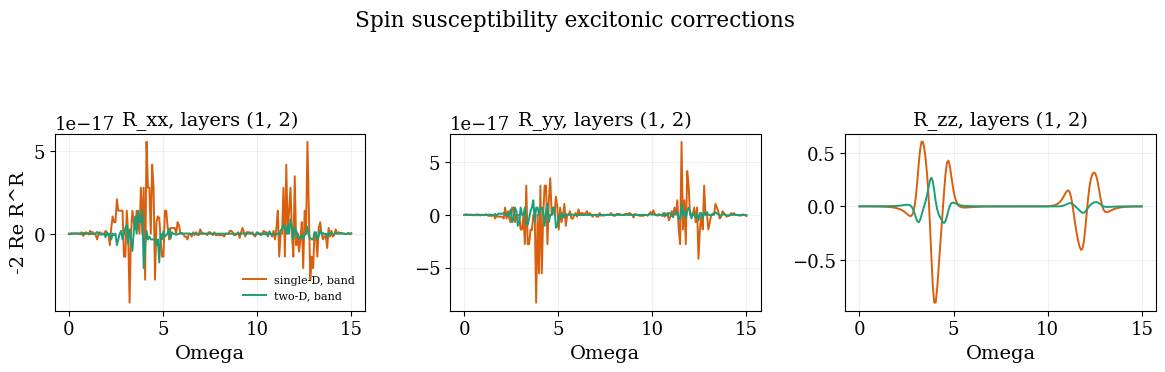

In [106]:
# Quick-look grids for the frequency-domain spin susceptibility figure.
Lχ = 100
Ωχ_min, Ωχ_max, NΩχ = 0.0, 15.0, 201
ωχ_min, ωχ_max, Nωχ = -15.0, 15.0, 321  # only used when vertex_methodχ = :langreth
ηDχ = 0.52#ηΩ
ηΛχ = 0.52#ηΩ

ksχ = collect(range(-π, stop=π - 2π/Lχ, length=Lχ))
Ωsχ = collect(range(Ωχ_min, Ωχ_max, length=NΩχ))
ωsχ = collect(range(ωχ_min, ωχ_max, length=Nωχ))

layer_pairχ = (1, 2)
vertex_methodχ = :band
plot_partχ = real#imag#real  # use imag for the absorptive part
ylabel_partχ = plot_partχ === real ? "Re" : "Im"

println("Computing D, R_1D, and R_2D for layer pair " * string(layer_pairχ) * "...")
# @time Rbareχ, layer_dataχ = spin_susceptibility_bare_band(Ωsχ, ksχ, θ)
@time Dχ, Πχ, dataDχ = precompute_exciton_D(Ωsχ, ksχ, θ; V=V, η=ηDχ)
D_metaχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, V=V, ηD=ηDχ, μ1=μ1, μ2=μ2)

if vertex_methodχ == :band
    @time R1Ddiagχ, Λdiagχ, dataΛχ = spin_susceptibility_oneD_diag_band(Dχ, Ωsχ, ksχ, θ; layer_pair=layer_pairχ, η=ηΛχ)
elseif vertex_methodχ == :langreth
    @time R1Ddiagχ, Λdiagχ = spin_susceptibility_oneD_diag_explicit_langreth(Dχ, Ωsχ, ωsχ, ksχ, θ; layer_pair=layer_pairχ, η=ηΛχ)
else
    error("Unknown vertex_methodχ: " * string(vertex_methodχ))
end
Λdiag_metaχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, ηΛ=ηΛχ, layer_pair=layer_pairχ, method=vertex_methodχ)

@time R2Ddiagχ, R2Dχ, Λoneχ, dataΛoneχ = spin_susceptibility_twoD_diag_band(Dχ, Ωsχ, ksχ, θ; layer_pair=layer_pairχ, η=ηΛχ)
Λone_metaχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, ηΛ=ηΛχ, method=:band)

fig, axs = subplots(1, 3, figsize=(12.0, 3.8), sharex=true)
for a in 1:3
    ax = axs[a]
    # Abare = [-2 * imag(Rbareχ[layer_pairχ[1], layer_pairχ[2], a, a, iΩ]) for iΩ in axes(Rbareχ, 5)]
    A1D = [-2 * plot_partχ(R1Ddiagχ[a, iΩ]) for iΩ in axes(R1Ddiagχ, 2)]
    A2D = [-2 * plot_partχ(R2Ddiagχ[a, iΩ]) for iΩ in axes(R2Ddiagχ, 2)]
    Atotal = A1D .+ A2D

    #ax.plot(Ωsχ, Abare, color="0.45", lw=1.5, label="bare")
    ax.plot(Ωsχ, A1D, color="#d95f0e", lw=1.4, label="single-D, " * string(vertex_methodχ))
    ax.plot(Ωsχ, A2D, color="#1b9e77", lw=1.4, label="two-D, band")
    #ax.plot(Ωsχ, Atotal, color="black", lw=1.8, label="single-D + two-D")
    ax.set_title("R_" * spin_labels[a] * spin_labels[a] * ", layers " * string(layer_pairχ))
    ax.set_xlabel("Omega")
    ax.grid(alpha=0.18)
end
axs[1].set_ylabel("-2 " * ylabel_partχ * " R^R")
axs[1].legend(frameon=false, fontsize=8)
fig.suptitle("Spin susceptibility excitonic corrections")
fig.tight_layout(rect=(0, 0, 1, 0.92))


## Diagnostic: exciton propagator $D^R$

This plot checks the collective excitonic propagator used in the single-$D$ spin-susceptibility correction. The left panel shows the channel-resolved spectral weight $-2\,\mathrm{Im}\,D^R_{\mu\mu}(\Omega)$. The right panel shows the eigenvalues of $D^R(\Omega)$; sharp features or sign changes here indicate collective excitonic resonances.


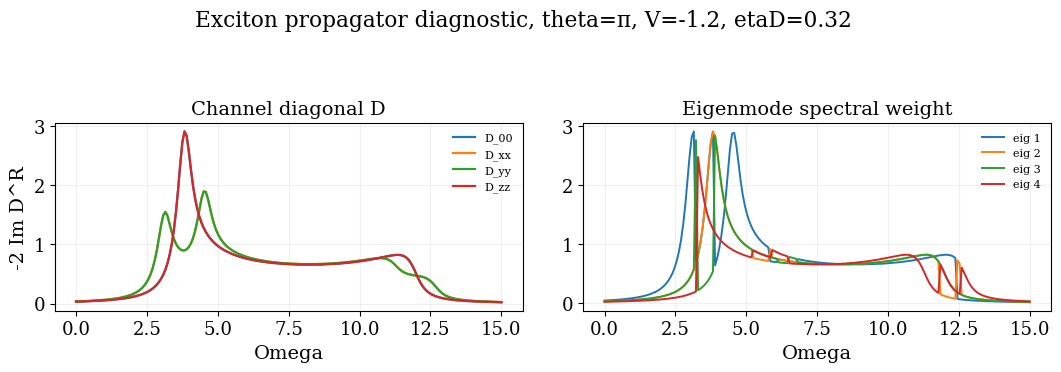

In [34]:
if !(@isdefined(ηDχ))
    ηDχ = ηΩ
end

D_meta_currentχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, V=V, ηD=ηDχ, μ1=μ1, μ2=μ2)
if !(@isdefined(Dχ)) || !(@isdefined(D_metaχ)) || D_metaχ != D_meta_currentχ
    @time Dχ, Πχ, dataDχ = precompute_exciton_D(Ωsχ, ksχ, θ; V=V, η=ηDχ)
    D_metaχ = D_meta_currentχ
end

Ddiag_spectral = [-2 * imag(Dχ[μ, μ, iΩ]) for μ in 1:4, iΩ in axes(Dχ, 3)]
Deig_spectral = zeros(Float64, 4, length(Ωsχ))
for iΩ in axes(Dχ, 3)
    vals = eigvals(Dχ[:, :, iΩ])
    order = sortperm(abs.(vals), rev=true)
    Deig_spectral[:, iΩ] .= [-2 * imag(vals[j]) for j in order]
end

fig, axs = subplots(1, 2, figsize=(11.0, 3.8), sharex=true)
for μ in 1:4
    axs[1].plot(Ωsχ, Ddiag_spectral[μ, :], lw=1.6, label="D_" * channel_labels[μ] * channel_labels[μ])
    axs[2].plot(Ωsχ, Deig_spectral[μ, :], lw=1.4, label="eig " * string(μ))
end
axs[1].set_title("Channel diagonal D")
axs[2].set_title("Eigenmode spectral weight")
for ax in axs
    ax.set_xlabel("Omega")
    ax.grid(alpha=0.18)
    ax.legend(frameon=false, fontsize=8)
end
axs[1].set_ylabel("-2 Im D^R")
fig.suptitle("Exciton propagator diagnostic, theta=" * string(θ) * ", V=" * string(V) * ", etaD=" * string(ηDχ))
fig.tight_layout(rect=(0, 0, 1, 0.90))


## Diagnostic: two-spin vertex $\Lambda^R$

This plot checks the reduced two-spin vertex entering the current layer-pair response. For each spin component $a=x,y,z$, the first three panels show the channel trace $\sum_\mu \Lambda^{ll',aa,R}_{\mu\mu}(\Omega)$. The last panel shows its channel Frobenius norm, useful for identifying where the vertex itself has large structure before contraction with $D^R$.

This diagnostic is not itself an observable. The trace can look jagged because the vertex contains higher-order denominators than $\Pi^R$ and is sensitive to finite-$k$ resolution and the broadening $\eta$. If this plot looks noisy, first compare against the norm and then increase `Lχ` or `ηΩ`.


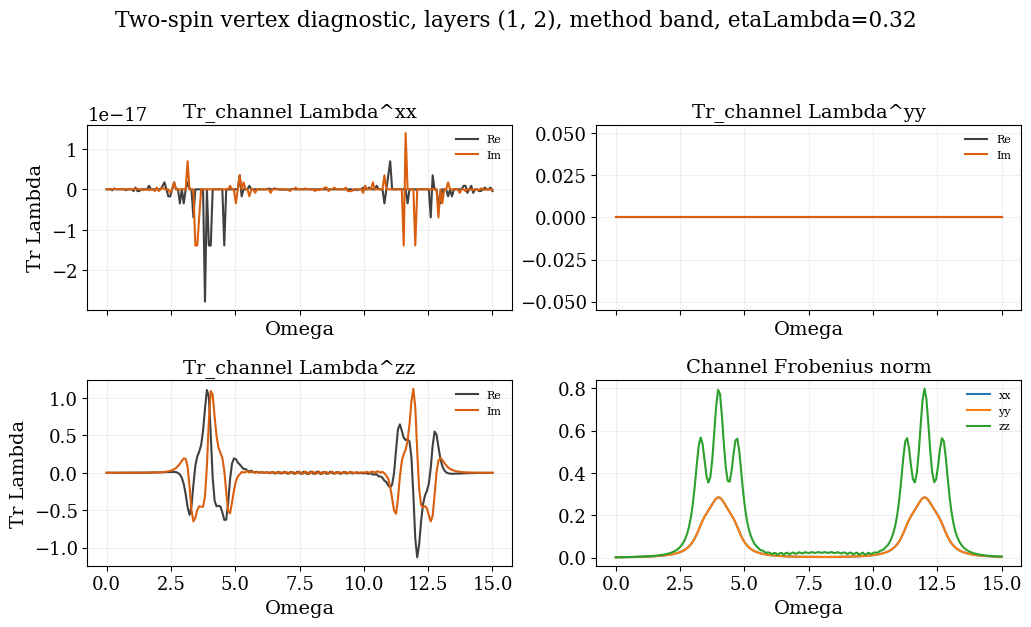

In [35]:
if !(@isdefined(ηDχ))
    ηDχ = ηΩ
end
if !(@isdefined(ηΛχ))
    ηΛχ = ηΩ
end

D_meta_currentχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, V=V, ηD=ηDχ, μ1=μ1, μ2=μ2)
if !(@isdefined(Dχ)) || !(@isdefined(D_metaχ)) || D_metaχ != D_meta_currentχ
    @time Dχ, Πχ, dataDχ = precompute_exciton_D(Ωsχ, ksχ, θ; V=V, η=ηDχ)
    D_metaχ = D_meta_currentχ
end

Λdiag_meta_currentχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, ηΛ=ηΛχ, layer_pair=layer_pairχ, method=vertex_methodχ)
if !(@isdefined(Λdiagχ)) || !(@isdefined(Λdiag_metaχ)) || Λdiag_metaχ != Λdiag_meta_currentχ
    if vertex_methodχ == :band
        @time R1Ddiagχ, Λdiagχ, dataΛχ = spin_susceptibility_oneD_diag_band(Dχ, Ωsχ, ksχ, θ; layer_pair=layer_pairχ, η=ηΛχ)
    elseif vertex_methodχ == :langreth
        @time R1Ddiagχ, Λdiagχ = spin_susceptibility_oneD_diag_explicit_langreth(Dχ, Ωsχ, ωsχ, ksχ, θ; layer_pair=layer_pairχ, η=ηΛχ)
    else
        error("Unknown vertex_methodχ: " * string(vertex_methodχ))
    end
    Λdiag_metaχ = Λdiag_meta_currentχ
end

Λtrace = zeros(ComplexF64, 3, length(Ωsχ))
Λnorm = zeros(Float64, 3, length(Ωsχ))
for a in 1:3, iΩ in axes(Λdiagχ, 4)
    Λtrace[a, iΩ] = sum(Λdiagχ[a, μ, μ, iΩ] for μ in 1:4)
    Λnorm[a, iΩ] = sqrt(sum(abs2, Λdiagχ[a, :, :, iΩ]))
end

fig, axs = subplots(2, 2, figsize=(10.5, 6.4), sharex=true)
axs_flat = [axs[1, 1], axs[1, 2], axs[2, 1], axs[2, 2]]
for a in 1:3
    ax = axs_flat[a]
    ax.plot(Ωsχ, real.(Λtrace[a, :]), color="0.25", lw=1.5, label="Re")
    ax.plot(Ωsχ, imag.(Λtrace[a, :]), color="#d95f0e", lw=1.5, label="Im")
    ax.set_title("Tr_channel Lambda^" * spin_labels[a] * spin_labels[a])
    ax.grid(alpha=0.18)
    ax.legend(frameon=false, fontsize=8)
end
for a in 1:3
    axs_flat[4].plot(Ωsχ, Λnorm[a, :], lw=1.5, label=spin_labels[a] * spin_labels[a])
end
axs_flat[4].set_title("Channel Frobenius norm")
axs_flat[4].grid(alpha=0.18)
axs_flat[4].legend(frameon=false, fontsize=8)
for ax in axs_flat
    ax.set_xlabel("Omega")
end
axs_flat[1].set_ylabel("Tr Lambda")
axs_flat[3].set_ylabel("Tr Lambda")
fig.suptitle("Two-spin vertex diagnostic, layers " * string(layer_pairχ) * ", method " * string(vertex_methodχ) * ", etaLambda=" * string(ηΛχ))
fig.tight_layout(rect=(0, 0, 1, 0.93))


## Explorer: individual components of $\Lambda^R$

Use this cell to inspect specific channel components $\Lambda^{ll',aa,R}_{\mu\nu}(\Omega)$ rather than only traces or norms. The parameters at the top are independent from the previous figures, so you can quickly change the layer pair, spin component, channels, vertex broadening `ηΛλ`, and frequency/momentum resolution.


Computing Lambda components with method band, layers (1, 2), spin zz, etaLambda 0.25...
 33.346037 seconds (1.24 G allocations: 28.018 GiB, 11.04% gc time, 0.05% compilation time)


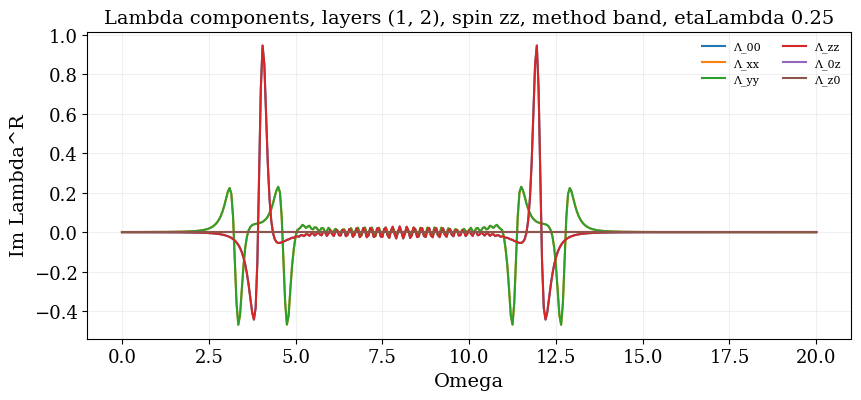

In [36]:
# -----------------------------
# Editable parameters for Lambda component exploration
# -----------------------------
lambda_method = :band          # :band or :langreth
lambda_layer_pair = (1, 2)    # (1,1), (1,2), (2,1), or (2,2)
lambda_spin_component = 3     # 1=x, 2=y, 3=z; this plots a=a
lambda_channel_pairs = [(1, 1), (2, 2), (3, 3), (4, 4), (1, 4), (4, 1)]
lambda_part = imag            # real, imag, or abs
lambda_part_label = lambda_part === real ? "Re" : lambda_part === imag ? "Im" : "Abs"

Lλ = 120
Ωλ_min, Ωλ_max, NΩλ = 0.0, 20.0, 401
ηΛλ = ηΩ

# Only used for lambda_method = :langreth.
ωλ_min, ωλ_max, Nωλ = -15.0, 15.0, 321

ksλ = collect(range(-π, stop=π - 2π/Lλ, length=Lλ))
Ωsλ = collect(range(Ωλ_min, Ωλ_max, length=NΩλ))
ωsλ = collect(range(ωλ_min, ωλ_max, length=Nωλ))

println("Computing Lambda components with method " * string(lambda_method) *
        ", layers " * string(lambda_layer_pair) *
        ", spin " * spin_labels[lambda_spin_component] * spin_labels[lambda_spin_component] *
        ", etaLambda " * string(ηΛλ) * "...")

if lambda_method == :band
    @time Λλ, dataΛλ = lambda_layerpair_diag_band(Ωsλ, ksλ, θ; layer_pair=lambda_layer_pair, η=ηΛλ)
elseif lambda_method == :langreth
    @time Λλ = lambda_layerpair_diag_explicit_langreth(Ωsλ, ωsλ, ksλ, θ; layer_pair=lambda_layer_pair, η=ηΛλ)
else
    error("Unknown lambda_method: " * string(lambda_method))
end

fig, ax = subplots(1, 1, figsize=(8.8, 4.2))
aλ = lambda_spin_component
for (μ, ν) in lambda_channel_pairs
    y = [lambda_part(Λλ[aλ, μ, ν, iΩ]) for iΩ in axes(Λλ, 4)]
    label = "Λ_" * channel_labels[μ] * channel_labels[ν]
    ax.plot(Ωsλ, y, lw=1.5, label=label)
end
ax.set_xlabel("Omega")
ax.set_ylabel(lambda_part_label * " Lambda^R")
ax.set_title("Lambda components, layers " * string(lambda_layer_pair) *
             ", spin " * spin_labels[aλ] * spin_labels[aλ] *
             ", method " * string(lambda_method) * ", etaLambda " * string(ηΛλ))
ax.grid(alpha=0.18)
ax.legend(frameon=false, fontsize=8, ncol=2)
fig.tight_layout()


## Diagnostic: full spin tensor $R^{ab}_{ll'}$

This figure plots the nine spin components for one selected layer pair. It is useful for checking components that are hidden in the diagonal-only view, for example $R^{zx}_{12}$ when the second magnetization lies in the $xz$ plane.

The full tensor is evaluated with the band-basis vertices. Use `tensor_sourceχ = :oneD`, `:twoD`, or `:sum` to choose which contribution is plotted.



In [ ]:
# -----------------------------
# Editable parameters for full spin-tensor component plot
# -----------------------------
tensor_layer_pairχ = layer_pairχ      # e.g. (1, 2)
tensor_sourceχ = :sum                 # :oneD, :twoD, or :sum
tensor_partχ = plot_partχ             # real, imag, or abs
tensor_part_labelχ = tensor_partχ === real ? "Re" : tensor_partχ === imag ? "Im" : "Abs"
tensor_zero_tolχ = 1e-10              # components below this are shown as exact zero

if !(@isdefined(ηDχ))
    ηDχ = ηΩ
end
if !(@isdefined(ηΛχ))
    ηΛχ = ηΩ
end

D_meta_currentχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, V=V, ηD=ηDχ, μ1=μ1, μ2=μ2)
if !(@isdefined(Dχ)) || !(@isdefined(D_metaχ)) || D_metaχ != D_meta_currentχ
    @time Dχ, Πχ, dataDχ = precompute_exciton_D(Ωsχ, ksχ, θ; V=V, η=ηDχ)
    D_metaχ = D_meta_currentχ
end

R1Dfull_meta_currentχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, ηΛ=ηΛχ, layer_pair=tensor_layer_pairχ, method=:band)
if !(@isdefined(R1Dfullχ)) || !(@isdefined(R1Dfull_metaχ)) || R1Dfull_metaχ != R1Dfull_meta_currentχ
    @time R1Dfullχ, Λfullχ, dataΛfullχ = spin_susceptibility_oneD_full_band(Dχ, Ωsχ, ksχ, θ; layer_pair=tensor_layer_pairχ, η=ηΛχ)
    R1Dfull_metaχ = R1Dfull_meta_currentχ
end

R2D_meta_currentχ = (NΩ=length(Ωsχ), L=length(ksχ), θ=θ, ηΛ=ηΛχ, method=:band)
if !(@isdefined(R2Dχ)) || !(@isdefined(R2D_metaχ)) || R2D_metaχ != R2D_meta_currentχ
    @time R2Dχ, Λoneχ, dataΛoneχ = spin_susceptibility_twoD_band(Dχ, Ωsχ, ksχ, θ; η=ηΛχ)
    R2D_metaχ = R2D_meta_currentχ
end

lχ, lpχ = tensor_layer_pairχ
R2Dlayerχ = R2Dχ[lχ, lpχ, :, :, :]
if tensor_sourceχ == :oneD
    Rtensorχ = R1Dfullχ
elseif tensor_sourceχ == :twoD
    Rtensorχ = R2Dlayerχ
elseif tensor_sourceχ == :sum
    Rtensorχ = R1Dfullχ .+ R2Dlayerχ
else
    error("Unknown tensor_sourceχ: " * string(tensor_sourceχ))
end

fig, axs = subplots(3, 3, figsize=(11.2, 8.0), sharex=true)
for a in 1:3, b in 1:3
    ax = axs[a, b]
    y = [-2 * tensor_partχ(Rtensorχ[a, b, iΩ]) for iΩ in axes(Rtensorχ, 3)]
    if maximum(abs.(y)) < tensor_zero_tolχ
        y .= 0.0
    else
        y = [abs(v) < tensor_zero_tolχ ? 0.0 : v for v in y]
    end
    ax.plot(Ωsχ, y, color="#2c7fb8", lw=1.45)
    ax.axhline(0.0, color="0.35", lw=0.6, alpha=0.45)
    ax.set_title("R_" * spin_labels[a] * spin_labels[b])
    ax.grid(alpha=0.16)
    if a == 3
        ax.set_xlabel("Omega")
    end
    if b == 1
        ax.set_ylabel("-2 " * tensor_part_labelχ * " R^R")
    end
end
fig.suptitle("Spin tensor components, layers " * string(tensor_layer_pairχ) * ", source " * string(tensor_sourceχ))
fig.tight_layout(rect=(0, 0, 1, 0.94))

